In [3]:
import pandas as pd
df=pd.read_csv(r'C:\Users\Rasulbek907\Desktop\LifeSpan_Peoples\Data\Feature_selection\Filtered_Features.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2022 non-null   int64  
 1   Unnamed: 0.2        2022 non-null   int64  
 2   name                2022 non-null   float64
 3   birth_date          2022 non-null   float64
 4   birth_place         2022 non-null   float64
 5   death_date          2022 non-null   float64
 6   death_place         2022 non-null   float64
 7   occupation          2022 non-null   float64
 8   awards              2022 non-null   float64
 9   alma_mater          2022 non-null   float64
 10  education           2022 non-null   float64
 11  spouse              2022 non-null   float64
 12  children            2022 non-null   float64
 13  occupation_cluster  2022 non-null   float64
 14  birth_year          2022 non-null   float64
 15  death_year          2022 non-null   float64
 16  life_s

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

In [6]:
n_samples = df.shape[0]

In [7]:
np.random.seed(42)

In [9]:
df['biased_target'] = (
    (df['life_span'] > df['life_span'].median()) &  
    (np.random.random(n_samples) < np.where(df['occupation_cluster'] <= df['occupation_cluster'].median(), 0.7, 0.9) * np.where(df['birth_year'] > 1950, 0.8, 0.6))).astype(int)

In [10]:
df[['life_span', 'occupation_cluster', 'birth_year', 'biased_target']].head()

,life_span,occupation_cluster,birth_year,biased_target
0,84.0,-0.628548,1643.0,0
1,67.0,-0.628548,1867.0,1
2,76.0,-0.628548,1879.0,1
3,37.0,-0.628548,1815.0,0
4,67.0,-0.628548,1452.0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2022 non-null   int64  
 1   Unnamed: 0.2        2022 non-null   int64  
 2   name                2022 non-null   float64
 3   birth_date          2022 non-null   float64
 4   birth_place         2022 non-null   float64
 5   death_date          2022 non-null   float64
 6   death_place         2022 non-null   float64
 7   occupation          2022 non-null   float64
 8   awards              2022 non-null   float64
 9   alma_mater          2022 non-null   float64
 10  education           2022 non-null   float64
 11  spouse              2022 non-null   float64
 12  children            2022 non-null   float64
 13  occupation_cluster  2022 non-null   float64
 14  birth_year          2022 non-null   float64
 15  death_year          2022 non-null   float64
 16  life_s

In [12]:
df.head()

,Unnamed: 0,Unnamed: 0.2,name,birth_date,birth_place,death_date,death_place,occupation,awards,alma_mater,...,spouse,children,occupation_cluster,birth_year,death_year,life_span,life_span_cluster,edu_award_cluster,bio_cluster,biased_target
0,0,0,-0.291212,-0.327866,1.812300,0.087552,0.863551,-0.513085,-0.028915,-0.279288,...,0.472636,-0.408171,-0.628548,1643.0,1727.0,84.0,2.0,1.272170,0.101081,0
1,1,1,0.318741,1.533003,1.601048,1.914421,1.470586,-0.513085,0.391234,2.474455,...,0.472636,-0.408171,-0.628548,1867.0,1934.0,67.0,2.0,-0.573778,-0.867573,1
2,2,2,-1.611324,-0.390376,1.503151,0.013399,1.563185,-0.513085,0.391234,-0.279288,...,0.472636,2.971872,-0.628548,1879.0,1955.0,76.0,2.0,-0.573778,-0.867573,1
3,3,3,1.251097,1.508961,-1.304951,1.880715,1.131058,-0.513085,0.391234,-0.279288,...,0.382327,3.464111,-0.628548,1815.0,1852.0,37.0,2.0,-0.573778,-0.867573,0
4,4,4,0.170609,1.316623,1.740165,1.563878,0.174206,-0.513085,0.391234,-0.279288,...,0.472636,-0.408171,-0.628548,1452.0,1519.0,67.0,5.0,1.272170,2.038390,0


In [13]:
sensitive_features = df[['occupation_cluster', 'birth_year']]
target = df['biased_target']
features = df.drop(columns=['biased_target'])


In [19]:
from sklearn.model_selection import train_test_split

X = df[['life_span', 'birth_year', 'occupation_cluster']]  
y = df['biased_target']  


A = df[['occupation_cluster']]


X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.2, random_state=42, stratify=y
)

print(len(y_test), len(A_test))

405 405


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

In [40]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [41]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [42]:
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.8074074074074075


In [43]:
dp_diff = demographic_parity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
print("Demographic Parity Difference:", dp_diff)

Demographic Parity Difference: 0.2802197802197802


In [44]:
eo_diff = equalized_odds_difference(y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
print("Equalized Odds Difference:", eo_diff)

Equalized Odds Difference: 0.6


In [45]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

dp_diff = demographic_parity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
eo_diff = equalized_odds_difference(y_true=y_test, y_pred=y_pred, sensitive_features=A_test)

print("Demographic Parity Difference:", dp_diff)
print("Equalized Odds Difference:", eo_diff)


Demographic Parity Difference: 0.2802197802197802
Equalized Odds Difference: 0.6


# Xulosa: Model juda biasli, ayniqsa occupation_cluster bo‘yicha.

# Fairlearn ExponentiatedGradient bilan in-processing mitigation

In [46]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

In [47]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [48]:
constraint = DemographicParity()

In [49]:
mitigated_model = ExponentiatedGradient(rf, constraint)
mitigated_model.fit(X_train, y_train, sensitive_features=A_train)

,estimator,RandomForestC...ndom_state=42)
,constraints,<fairlearn.re...0024DF1845400>
,objective,None
,eps,0.01
,max_iter,50
,nu,np.float64(0.0)
,eta0,2.0
,run_linprog_step,True
,sample_weight_name,'sample_weight'
,n_estimators,100
,criterion,'gini'


In [50]:
y_pred_mitigated = mitigated_model.predict(X_test)

In [51]:
acc_mitigated = accuracy_score(y_test, y_pred_mitigated)
dp_diff_mitigated = demographic_parity_difference(y_test, y_pred_mitigated, sensitive_features=A_test)
eo_diff_mitigated = equalized_odds_difference(y_test, y_pred_mitigated, sensitive_features=A_test)

In [52]:
print("Mitigated Model Accuracy:", acc_mitigated)
print("Mitigated Model Demographic Parity Difference:", dp_diff_mitigated)
print("Mitigated Model Equalized Odds Difference:", eo_diff_mitigated)

Mitigated Model Accuracy: 0.7876543209876543
Mitigated Model Demographic Parity Difference: 0.17647058823529413
Mitigated Model Equalized Odds Difference: 0.3333333333333333


# Tahlil:

Accuracy biroz pasaydi (0.807 → 0.788), bu normal, chunki bias kamaytirildi.

DPD kamaydi (0.28 → 0.176) → sensitive feature bo‘yicha positive prediction farqi kamaydi.

EOD ham kamaydi (0.6 → 0.333) → true/false positive farqi kamaydi.

Xulosa:

Model endi ancha adolatli.

Biased modelga qaraganda, sensitive feature ta’siri kamaydi.

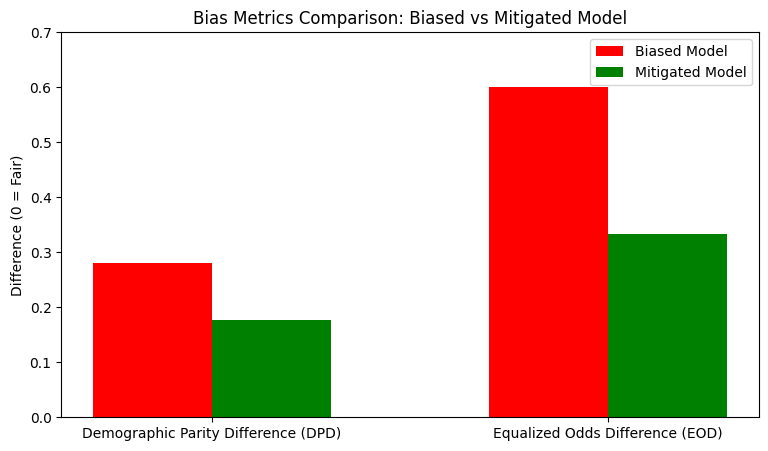

In [54]:
import matplotlib.pyplot as plt

# Metrics
metrics = ['Demographic Parity Difference (DPD)', 'Equalized Odds Difference (EOD)']

# Biased model qiymatlari
biased_values = [0.2802197802197802, 0.6]

# Mitigated model qiymatlari
mitigated_values = [0.17647058823529413, 0.3333333333333333]

# Bar chart tayyorlash
x = range(len(metrics))
plt.figure(figsize=(9,5))

plt.bar([i-0.15 for i in x], biased_values, width=0.3, color='red', label='Biased Model')
plt.bar([i+0.15 for i in x], mitigated_values, width=0.3, color='green', label='Mitigated Model')

# Labels va title
plt.xticks(x, metrics)
plt.ylabel("Difference (0 = Fair)")
plt.title("Bias Metrics Comparison: Biased vs Mitigated Model")
plt.legend()
plt.ylim(0, max(max(biased_values), max(mitigated_values)) + 0.1)

# Show plot
plt.show()
